<a href="https://colab.research.google.com/github/shebbir007/Python_Learning_Basics/blob/main/Deep_Learning_Mini_Project_Lecture_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
print('TF Version:',tf.__version__)


TF Version: 2.19.0


**Convolution**

In [6]:
#Simple 4x4 image
image= np.array([[1*2,0,1,0],
[0,1,3,2],
[2,1,0,1],
[1,0,1,2]], dtype=float)
#2x2 kernel (filter)
kernel = np.array([[1, 0],
[0,-1]], dtype=float)
print('Image:')
print(image)
#print(image.astype(int))
print('\nkernel:')
print(kernel)

Image:
[[2. 0. 1. 0.]
 [0. 1. 3. 2.]
 [2. 1. 0. 1.]
 [1. 0. 1. 2.]]

kernel:
[[ 1.  0.]
 [ 0. -1.]]


**# Sliding**

In [8]:
# Slide the kernel over the image (manual convolution)
output = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        patch = image[i:i+2, j:j+2]
        output[i, j] = np.sum(patch * kernel)
print('Convolution Result:')
print(output)

Convolution Result:
[[ 1. -3. -1.]
 [-1.  1.  2.]
 [ 2.  0. -2.]]


# **Mini Project**

In [10]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Input

In [14]:
#Load images from folders
DATA = '/content/drive/MyDrive/datasets/plantvillage'
train_ds = keras.utils.image_dataset_from_directory(
    DATA + '/train',
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical' # Changed from 'multy' to 'categorical'
)
test_ds = keras.utils.image_dataset_from_directory(
    DATA + '/test',
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical' # Changed from 'multy' to 'categorical'
)

Found 1721 files belonging to 3 classes.
Found 431 files belonging to 3 classes.


Normalize

In [15]:
#Normalize pixel values from [0,255] to [0,1]
def normalize(img, label):
    return img / 255.0, label
train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [17]:
#Build a simple CNN
model = keras.Sequential ([
keras.Input (shape=(128, 128, 3)),
layers.Conv2D(16, 3, activation='relu', padding='same'),
layers.MaxPooling2D(2),
layers.Conv2D(32, 3, activation='relu', padding='same'),
layers.MaxPooling2D(2),
layers.Flatten(),
layers.Dense (32, activation='relu'),
layers.Dense (3, activation='softmax') # Changed from 1 and sigmoid to 3 and softmax for 3 classes
])

model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │     1,048,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,053,795 (4.02 MB)

 Trainable params: 1,053,795 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Training

from IPython.core import history
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 527s 10s/step - accuracy: 0.7234 - loss: 0.7168 - val_accuracy: 0.9026 - val_loss: 0.3260
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.8942 - loss: 0.2615 - val_accuracy: 0.8724 - val_loss: 0.2722
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9285 - loss: 0.1851 - val_accuracy: 0.9466 - val_loss: 0.1495
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.9605 - loss: 0.1183 - val_accuracy: 0.9420 - val_loss: 0.1523
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.9709 - loss: 0.0922 - val_accuracy: 0.9559 - val_loss: 0.1124
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9709 - loss: 0.0709 - val_accuracy: 0.9652 - val_loss: 0.0952
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.9901 - loss: 0.0390 - val_accuracy: 0.9652 - val_loss: 0.1007
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.9907 - loss: 0.0348 - val_accuracy: 0

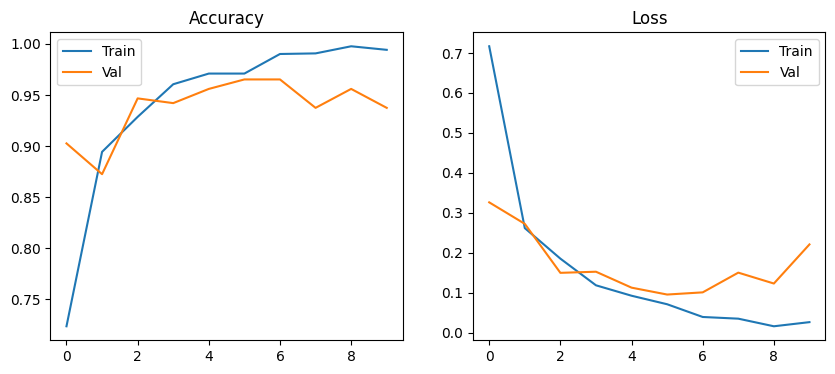

In [19]:
#Plot accuracy and loss
fig, (ax1, ax2) = plt.subplots (1, 2, figsize=(10, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.legend()
plt.show()

In [24]:
# Evaluate on test set
loss, acc = model.evaluate(test_ds)
print(f'Test Accuracy: {acc:.2%}')
print(f'Test Loss : {loss:.4f}')

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.9374 - loss: 0.2207
Test Accuracy: 93.74%
Test Loss : 0.2207


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Get true labels and predictions
true_labels = []
predicted_probs = []

for images, labels in test_ds:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    predicted_probs.extend(model.predict(images))

predicted_labels = np.argmax(np.array(predicted_probs), axis=1)

# Calculate metrics
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')

print(f'Precision: {precision:.2%}')
print(f'Recall: {recall:.2%}')
print(f'F1-Score: {f1:.2%}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Precision: 94.28%
Recall: 93.74%
F1-Score: 93.74%


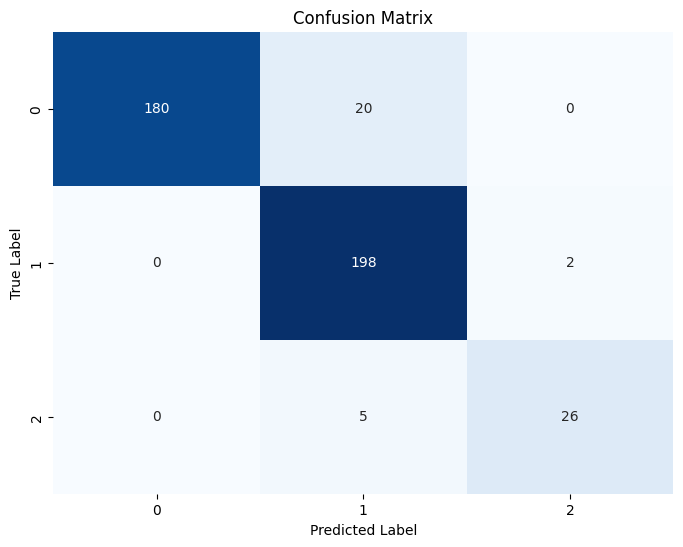

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [27]:
import pandas as pd

# Create a dictionary of metrics
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [acc, precision, recall, f1]
}

# Create a DataFrame
metrics_df = pd.DataFrame(metrics_data)

print('Comparison Table of Metrics:')
display(metrics_df.set_index('Metric').style.format({'Value': '{:.2%}'}))

Comparison Table of Metrics:


,Value
Metric,
Accuracy,93.74%
Precision,94.28%
Recall,93.74%
F1-Score,93.74%
